<a href="https://colab.research.google.com/github/esther119/Bayesian-Statistics/blob/main/CS146_Session_12_Central_limit_theorem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Using the normal approximation to the binomial distribution, confirm that the 95%
confidence interval for the sampling error for sample size 1000 and percentage outcome
10% is 2% (rounded to the nearest integer). Also, motivate why it is appropriate to use
the binomial distribution here.

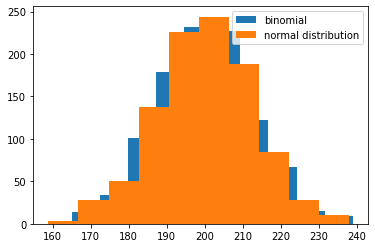

In [44]:
from scipy import stats
import numpy as np
from matplotlib import pyplot as plt

p = 0.2
n = 1000
q = 1 - p

mu = n*p
sigma = np.sqrt(n*p*q)


samples = stats.binom.rvs(n, p, size=1000)
norm = stats.norm(loc=mu, scale=sigma)

norm_samples = stats.norm.rvs(loc=mu, scale=sigma, size=n)

x = np.linspace(0, 300, 200)
plt.hist(samples, label = 'binomial')
plt.hist(norm_samples, label = 'normal distribution')
plt.legend()

In [23]:
margin = round(np.sqrt(p*q/n)*1.96, 2)

print(f"Using binomial distribution, we get that the margin of error for size {n} and percentage {p} is {margin}")

Using binomial distribution, we get that the margin of error for size 1000 and percentage 0.2 is 0.02


2. Write a Python function for calculating the 95% confidence interval given any sample
size and any percentage outcome. Use your function to calculate all the values in the
Total Survey Error table rounded to the nearest integer. For which entries does your
margin of error differ from the value in the table?

In [45]:
import pandas as pd

def ci_95(p, n):
    p = p/100
    return round(np.sqrt(p*(1-p)/n)*1.96, 2)

df0 = pd.DataFrame()
for j in [1000, 750, 500, 250, 100]:
    df0[j] = [ci_95(i, j) for i in range(10, 91, 10)]
    
df0.index = [i/10 for i in range(1, 10, 1)]
df0

,1000,750,500,250,100
0.1,0.02,0.02,0.03,0.04,0.06
0.2,0.02,0.03,0.04,0.05,0.08
0.3,0.03,0.03,0.04,0.06,0.09
0.4,0.03,0.04,0.04,0.06,0.10
0.5,0.03,0.04,0.04,0.06,0.10
0.6,0.03,0.04,0.04,0.06,0.10
0.7,0.03,0.03,0.04,0.06,0.09
0.8,0.02,0.03,0.04,0.05,0.08
0.9,0.02,0.02,0.03,0.04,0.06


Column n = 100 has most of the errors. 

3. Can you identify where these errors come from?

1. Rounding error
2. Sampling size. 100 is the smallest sample size so it can be easily affected by extreme value. 